In [52]:
##### Overlays capital and labor AND INCOME with priority maps: calculations and figures

import os
import textwrap
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.transforms as transforms
from matplotlib import gridspec
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import numpy as np
import pandas as pd
import rioxarray
import xarray as xr
from scipy.signal import savgol_filter

import rasterio
import rasterio.features
from rasterio.enums import Resampling
from rasterio.plot import show

In [53]:
##### Load data

# Get the current working directory
cd = Path.cwd().parent 

# capital rasters
capital = f"{cd}/Results/Raster_model/reprojected/rescaled_capital_USD.tif"
capital_country_avg = f"{cd}/Results/Raster_model/reprojected/rescaled_capital_USD_country_avg.tif"

# labor rasters
labor = f"{cd}/Results/Raster_model/reprojected/rescaled_jobs.tif"
labor_country_avg = f"{cd}/Results/Raster_model/reprojected/rescaled_jobs_country_avg.tif"

# production raster
production = f"{cd}/Results/Raster_model/reprojected/total_production_tonnes_2020.tif"

# GDP pc percentile rasters
GDP_pc_percentiles_national = f"{cd}/Data/Clean/GDP_percentiles/GDP_pc_percentiles_reprojected.tif"
GDP_pc_percentiles_global = f"{cd}/Data/Clean/GDP_percentiles/global_GDP_pc_percentiles_reprojected.tif"

# priority rasters
# 0 = no in top 30%, 1 = in top 30%, not PA, 2 = in top 30%, already PA
biodiversity_with_PA = f"{cd}/Data/Clean/Priority_areas/biodiversity_with_PA.tif"
all_with_PA = f"{cd}/Data/Clean/Priority_areas/all_with_PA.tif"

# country boundaries 
country_shp = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')
country_codes = pd.read_csv(f"{cd}/Data/Correspondence_tables/country_names.csv", encoding="cp1252")

# Import country data
national_capital = pd.read_csv(f"{cd}/Results/Raster_model/intermediate_outputs/national_scaling_factors_capital.csv")
national_labor = pd.read_csv(f"{cd}/Results/Raster_model/intermediate_outputs/national_scaling_factors_labor.csv")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/priority_areas"

In [27]:
### Step 1: align rasters

# --- Load everything as DataArrays ---
capital_da              = rioxarray.open_rasterio(capital, masked=True)
capital_avg_da          = rioxarray.open_rasterio(capital_country_avg, masked=True)
labor_da                = rioxarray.open_rasterio(labor, masked=True)
labor_avg_da            = rioxarray.open_rasterio(labor_country_avg, masked=True)
gdp_pc_national_da      = rioxarray.open_rasterio(GDP_pc_percentiles_national, masked=True)
gdp_pc_global_da        = rioxarray.open_rasterio(GDP_pc_percentiles_global, masked=True)
biodiversity_da         = rioxarray.open_rasterio(biodiversity_with_PA, masked=True)
all_da                  = rioxarray.open_rasterio(all_with_PA, masked=True)
production_da           = rioxarray.open_rasterio(production, masked=True)
# --- Align everything to the national percentile grid (arbitrary common reference) ---
def match_grid(da, target):
    return da.rio.reproject_match(target, resampling=Resampling.nearest)

capital_da       = match_grid(capital_da, gdp_pc_national_da)
capital_avg_da   = match_grid(capital_avg_da, gdp_pc_national_da)
labor_da         = match_grid(labor_da, gdp_pc_national_da)
labor_avg_da     = match_grid(labor_avg_da, gdp_pc_national_da)
gdp_pc_global_da = match_grid(gdp_pc_global_da, gdp_pc_national_da)
biodiversity_da  = match_grid(biodiversity_da, gdp_pc_national_da)
all_da           = match_grid(all_da, gdp_pc_national_da)
production_da    = match_grid(production_da, gdp_pc_national_da)

percentile_lookup = {'national': gdp_pc_national_da, 'global': gdp_pc_global_da}
priority_lookup    = {'biodiversity': biodiversity_da, 'all': all_da}

In [15]:
##### Step 2: get priority area totals

def summarize_priority_totals(scenario='biodiversity'):
    """Sum capital/labor (modeled + country avg) split into 'Not priority' vs 'Priority area'."""
    priority_da = priority_lookup[scenario]
    priority_arr = priority_da.squeeze().values

    value_arrs = {
        'capital_modeled':     capital_da.squeeze().values,
        'capital_country_avg': capital_avg_da.squeeze().values,
        'labor_modeled':       labor_da.squeeze().values,
        'labor_country_avg':   labor_avg_da.squeeze().values,
    }

    categories = {
        'Not priority':   priority_arr == 0,
        'Priority area':  priority_arr >= 1,   # combines "additional" + "already PA"
    }

    rows = []
    for cat_name, mask in categories.items():
        row = {'scenario': scenario, 'category': cat_name, 'n_pixels': int(np.sum(mask))}
        for val_name, val_arr in value_arrs.items():
            row[val_name] = np.nansum(val_arr[mask])
        rows.append(row)
    return pd.DataFrame(rows)

summarize_priority_totals('biodiversity')

,scenario,category,n_pixels,capital_modeled,capital_country_avg,labor_modeled,labor_country_avg
0,biodiversity,Not priority,973316,4.526319e+12,4.595703e+12,726739968.0,735817152.0
1,biodiversity,Priority area,417913,8.331266e+11,7.638572e+11,117386112.0,108360680.0


In [16]:
##### Step 3: define functions for plot 

def pct_by_percentile_within_mask(var_da, pctl_da, priority_mask):
    """% of the priority-area total for var, broken out by GDP-pc percentile (1-100)."""
    var  = var_da.squeeze().values.astype(float)
    pctl = pctl_da.squeeze().values.astype(float)

    nodata_var = var_da.rio.nodata
    if nodata_var is not None:
        var = np.where(var == nodata_var, np.nan, var)
    nodata_pctl = pctl_da.rio.nodata
    if nodata_pctl is not None:
        pctl = np.where(pctl == nodata_pctl, np.nan, pctl)

    valid = (~np.isnan(var) & ~np.isnan(pctl) & (pctl >= 1) & (pctl <= 100)
             & priority_mask)

    var_v  = var[valid]
    pctl_v = np.round(pctl[valid]).astype(int)

    total = np.nansum(var_v)  # total within priority area only

    df = pd.DataFrame({"percentile": pctl_v, "value": var_v})
    grouped = df.groupby("percentile")["value"].sum().reindex(range(1, 101), fill_value=0)

    return (grouped / total) * 100 if total > 0 else grouped


def smooth(series, window=9, polyorder=2):
    smoothed = savgol_filter(series.values, window_length=window, polyorder=polyorder, mode="interp")
    return pd.Series(smoothed, index=series.index)


def plot_capital_labor_priority(scenario='biodiversity', percentile_scope='national', save=True):
    """
    scenario: 'biodiversity' or 'all'
    percentile_scope: 'national' or 'global'
    """
    priority_da  = priority_lookup[scenario]
    pctl_da      = percentile_lookup[percentile_scope]
    priority_mask = priority_da.squeeze().values >= 1  # priority area = tier 1 or 2

    capital_pct     = smooth(pct_by_percentile_within_mask(capital_da, pctl_da, priority_mask))
    capital_avg_pct = smooth(pct_by_percentile_within_mask(capital_avg_da, pctl_da, priority_mask))
    labor_pct       = smooth(pct_by_percentile_within_mask(labor_da, pctl_da, priority_mask))
    labor_avg_pct   = smooth(pct_by_percentile_within_mask(labor_avg_da, pctl_da, priority_mask))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    ax = axes[0]
    ax.plot(capital_pct.index, capital_pct.values, label="Capital (modeled)",
            color="#1b9e77", linewidth=2)
    ax.plot(capital_avg_pct.index, capital_avg_pct.values, label="Capital (country avg)",
            color="#1b9e77", linewidth=2, linestyle="--")
    ax.set_xlabel(f"GDP pc percentile ({percentile_scope})")
    ax.set_ylabel("% of total exposed (within priority area)")
    ax.set_title("Capital")
    ax.set_xlim(1, 100)
    ax.legend(frameon=False)

    ax = axes[1]
    ax.plot(labor_pct.index, labor_pct.values, label="Labor (modeled)",
            color="#d95f02", linewidth=2)
    ax.plot(labor_avg_pct.index, labor_avg_pct.values, label="Labor (country avg)",
            color="#d95f02", linewidth=2, linestyle="--")
    ax.set_xlabel(f"GDP pc percentile ({percentile_scope})")
    ax.set_title("Labor")
    ax.set_xlim(1, 100)
    ax.legend(frameon=False)

    fig.suptitle(f"{scenario.capitalize()} scenario — priority-area exposure by {percentile_scope} income percentile",
                 y=1.03)
    plt.tight_layout()

    if save:
        plt.savefig(f"{fd}/priority_exposure_{scenario}_{percentile_scope}.png", dpi=300, bbox_inches="tight")
        plt.savefig(f"{fd}/priority_exposure_{scenario}_{percentile_scope}.pdf", bbox_inches="tight")
    plt.show()
    return fig

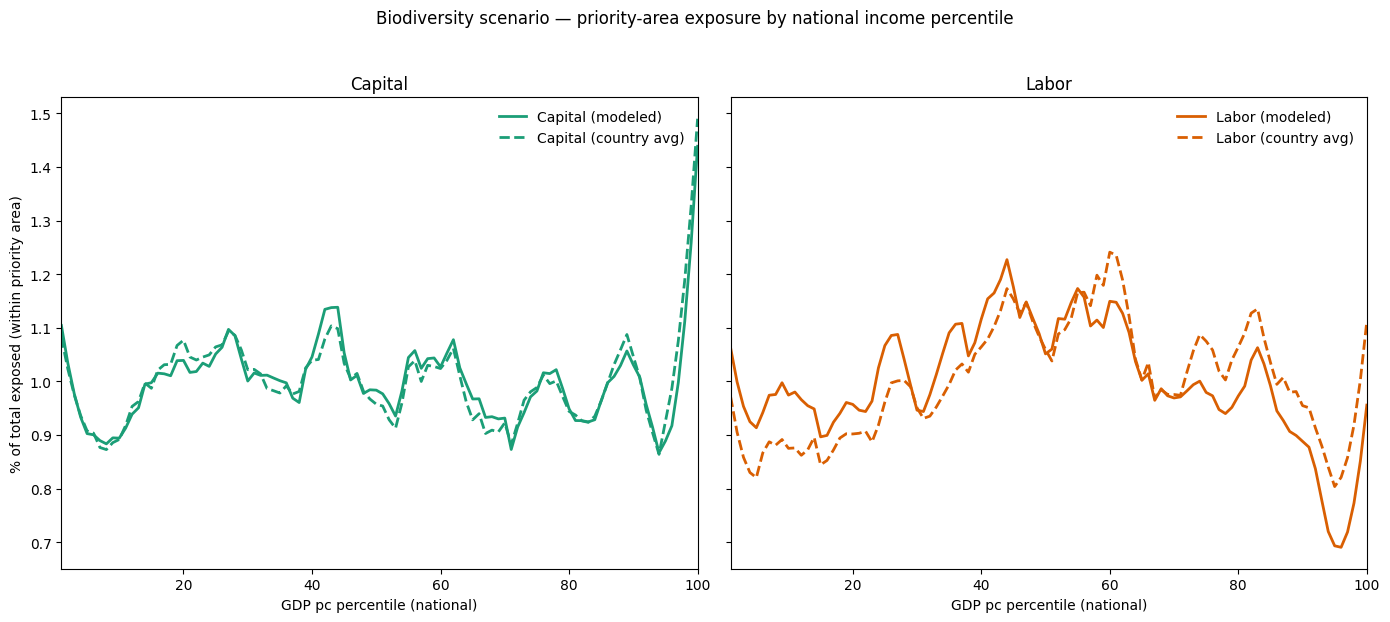

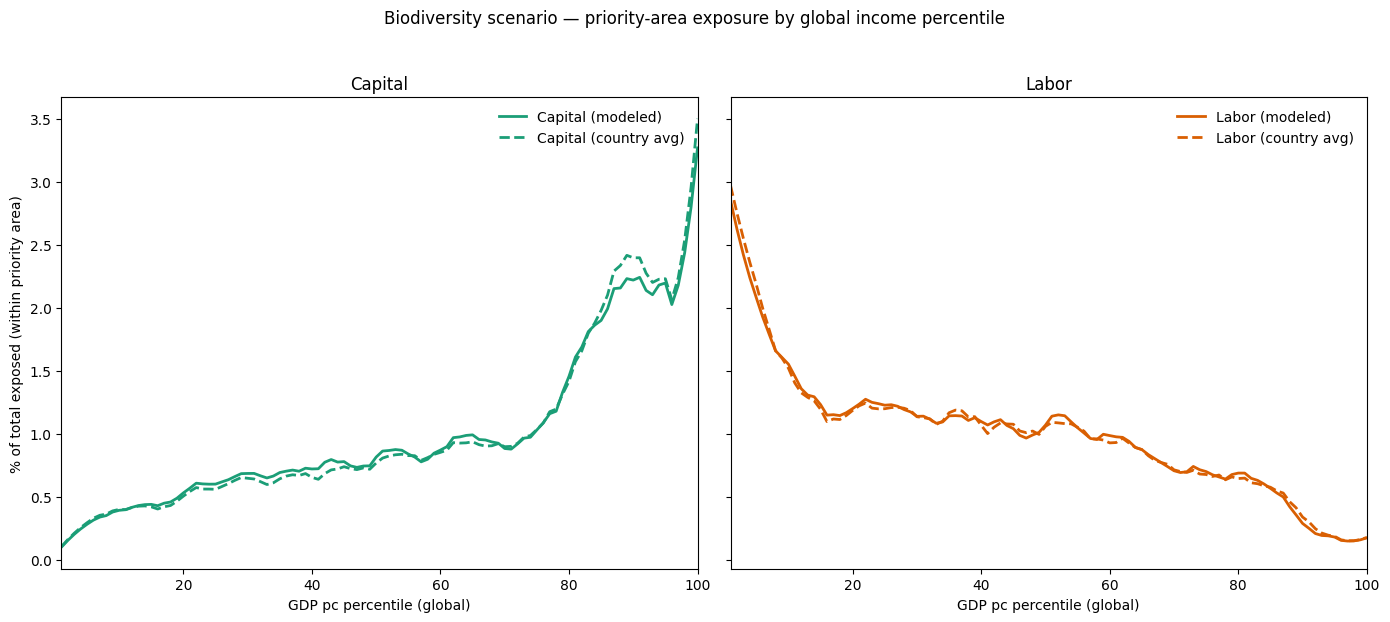

In [51]:
#### Run plots
plot_capital_labor_priority(scenario='biodiversity', percentile_scope='national');
plot_capital_labor_priority(scenario='biodiversity', percentile_scope='global');

/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_1128/2682992312.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(y, x)          # area under the concentration curve


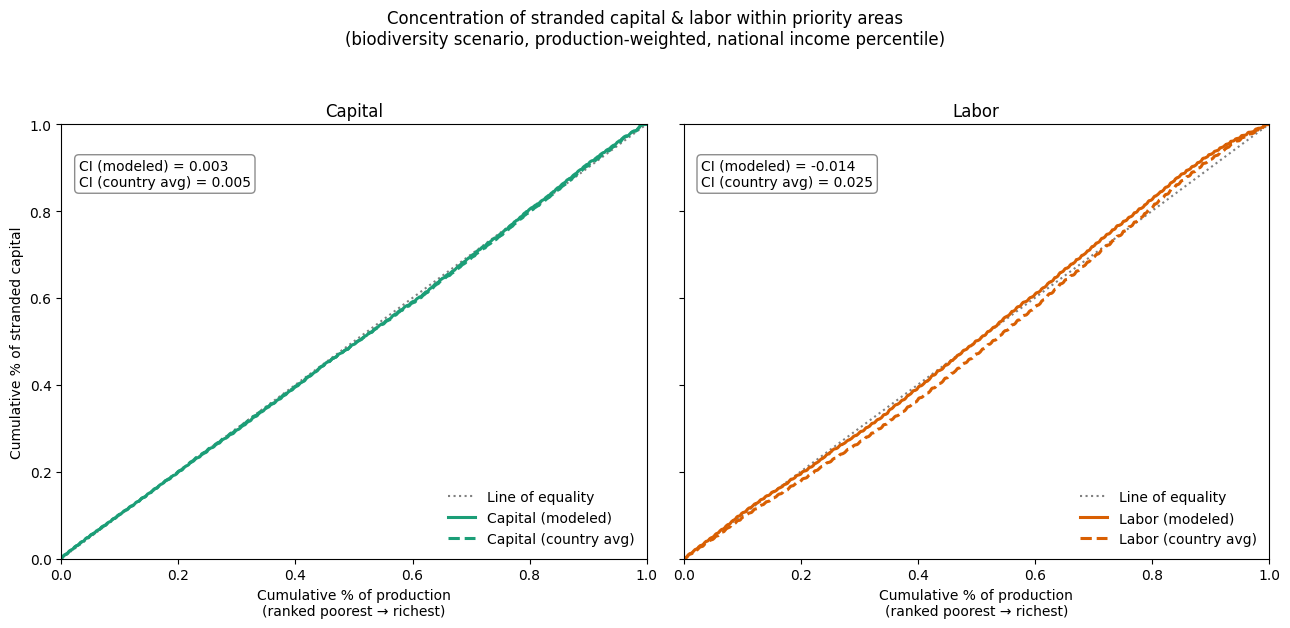

/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_1128/2682992312.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(y, x)          # area under the concentration curve


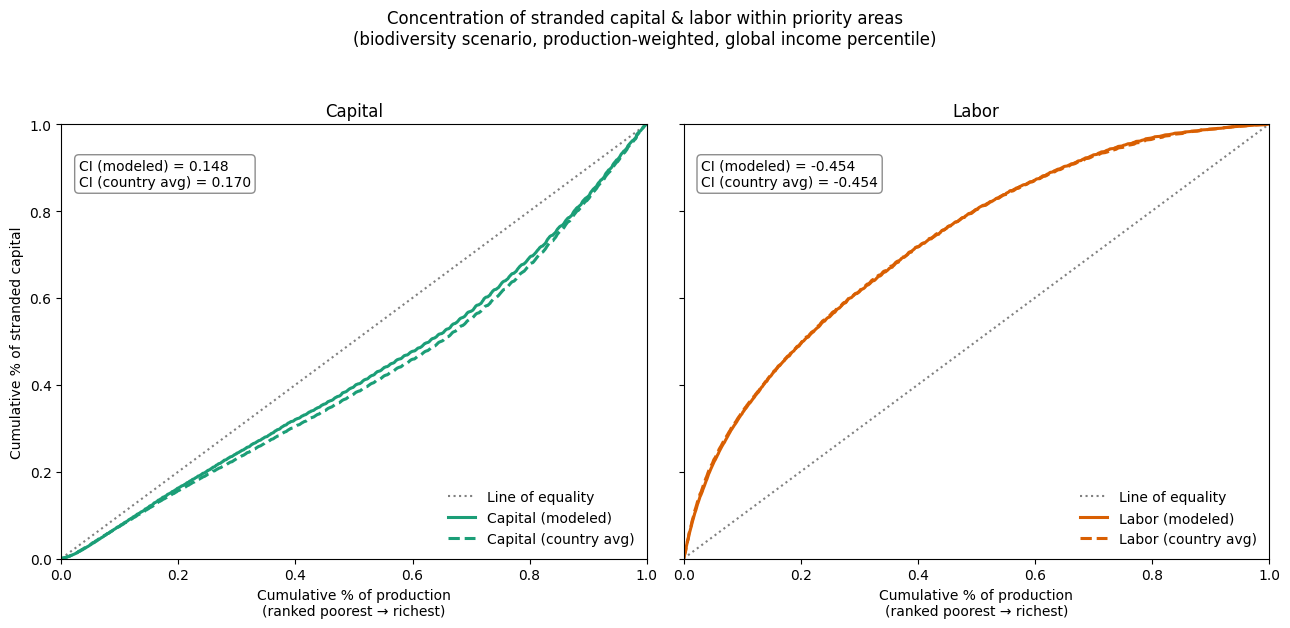

In [28]:
def concentration_curve_data(value_da, weight_da, pctl_da, priority_mask):
    """
    Rank priority-area pixels by income percentile (ascending), then compute
    cumulative share of `weight` (production, x-axis) vs cumulative share of
    `value` (capital or labor, y-axis). Returns (x, y, concentration_index).
    """
    value  = value_da.squeeze().values.astype(float)
    weight = weight_da.squeeze().values.astype(float)
    pctl   = pctl_da.squeeze().values.astype(float)

    for da, arr_name in [(value_da, 'value'), (weight_da, 'weight'), (pctl_da, 'pctl')]:
        nodata = da.rio.nodata
        if nodata is not None:
            locals()[arr_name][locals()[arr_name] == nodata] = np.nan  # noqa (see note below)

    # explicit nodata handling (avoids the locals() hack above — safer):
    if value_da.rio.nodata is not None:
        value = np.where(value == value_da.rio.nodata, np.nan, value)
    if weight_da.rio.nodata is not None:
        weight = np.where(weight == weight_da.rio.nodata, np.nan, weight)
    if pctl_da.rio.nodata is not None:
        pctl = np.where(pctl == pctl_da.rio.nodata, np.nan, pctl)

    valid = (~np.isnan(value) & ~np.isnan(weight) & ~np.isnan(pctl)
             & (pctl >= 1) & (pctl <= 100) & priority_mask & (weight > 0))

    v = value[valid]
    w = weight[valid]
    p = pctl[valid]

    order = np.argsort(p, kind="mergesort")  # stable sort, ties keep pixel order
    v, w = v[order], w[order]

    cum_w = np.cumsum(w) / np.sum(w)
    cum_v = np.cumsum(v) / np.sum(v)

    x = np.concatenate([[0], cum_w])
    y = np.concatenate([[0], cum_v])

    auc = np.trapz(y, x)          # area under the concentration curve
    ci = 1 - 2 * auc              # concentration index; negative = pro-poor concentration

    return x, y, ci


def plot_concentration_curve(percentile_scope='national', save=True, show=True):
    scenario = 'biodiversity'
    priority_da   = priority_lookup[scenario]
    pctl_da       = percentile_lookup[percentile_scope]
    priority_mask = priority_da.squeeze().values >= 1

    x_cap, y_cap, ci_cap         = concentration_curve_data(capital_da, production_da, pctl_da, priority_mask)
    x_cap_avg, y_cap_avg, ci_cap_avg = concentration_curve_data(capital_avg_da, production_da, pctl_da, priority_mask)
    x_lab, y_lab, ci_lab         = concentration_curve_data(labor_da, production_da, pctl_da, priority_mask)
    x_lab_avg, y_lab_avg, ci_lab_avg = concentration_curve_data(labor_avg_da, production_da, pctl_da, priority_mask)

    fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True, sharex=True)

    # --- Capital panel ---
    ax = axes[0]
    ax.plot([0, 1], [0, 1], color="grey", linestyle=":", linewidth=1.5, label="Line of equality")
    ax.plot(x_cap, y_cap, color="#1b9e77", linewidth=2.2, label="Capital (modeled)")
    ax.plot(x_cap_avg, y_cap_avg, color="#1b9e77", linewidth=2.2, linestyle="--", label="Capital (country avg)")
    ax.set_xlabel("Cumulative % of production\n(ranked poorest → richest)")
    ax.set_ylabel("Cumulative % of stranded capital")
    ax.set_title("Capital")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.text(0.03, 0.92, f"CI (modeled) = {ci_cap:.3f}\nCI (country avg) = {ci_cap_avg:.3f}",
            transform=ax.transAxes, fontsize=10, va="top",
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="grey", alpha=0.9))
    ax.legend(frameon=False, loc="lower right")

    # --- Labor panel ---
    ax = axes[1]
    ax.plot([0, 1], [0, 1], color="grey", linestyle=":", linewidth=1.5, label="Line of equality")
    ax.plot(x_lab, y_lab, color="#d95f02", linewidth=2.2, label="Labor (modeled)")
    ax.plot(x_lab_avg, y_lab_avg, color="#d95f02", linewidth=2.2, linestyle="--", label="Labor (country avg)")
    ax.set_xlabel("Cumulative % of production\n(ranked poorest → richest)")
    ax.set_title("Labor")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.text(0.03, 0.92, f"CI (modeled) = {ci_lab:.3f}\nCI (country avg) = {ci_lab_avg:.3f}",
            transform=ax.transAxes, fontsize=10, va="top",
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="grey", alpha=0.9))
    ax.legend(frameon=False, loc="lower right")

    fig.suptitle(f"Concentration of stranded capital & labor within priority areas\n"
                 f"(biodiversity scenario, production-weighted, {percentile_scope} income percentile)", y=1.04)
    plt.tight_layout()

    if save:
        plt.savefig(f"{fd}/concentration_curve_biodiversity_{percentile_scope}.png", dpi=300, bbox_inches="tight")
        plt.savefig(f"{fd}/concentration_curve_biodiversity_{percentile_scope}.pdf", bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)


plot_concentration_curve(percentile_scope='national')
plot_concentration_curve(percentile_scope='global')

In [36]:
### Step 1b: country masking utility

country_mask_cache = {}

def get_country_mask(gid0, target_da=gdp_pc_national_da):
    """
    Rasterize a single country's outline (matched by GID_0) onto the same
    grid used for capital/labor/priority rasters. Returns a boolean array
    (True = inside the country).
    """
    if gid0 in country_mask_cache:
        return country_mask_cache[gid0]

    geom = country_shp[country_shp['GID_0'] == gid0]
    if geom.empty:
        raise ValueError(f"No country found with GID_0 == '{gid0}'. "
                          f"Check country_shp['GID_0'].unique() for valid codes.")

    geom_proj = geom.to_crs(target_da.rio.crs)

    transform = target_da.rio.transform()
    out_shape = target_da.squeeze().shape

    mask = rasterio.features.geometry_mask(
        geom_proj.geometry,
        out_shape=out_shape,
        transform=transform,
        invert=True  # True = inside the country boundary
    )

    country_mask_cache[gid0] = mask
    return mask

In [40]:
def plot_capital_labor_priority(scenario='biodiversity', percentile_scope='national',
                                 country=None, save=True):
    """
    scenario: 'biodiversity' or 'all'
    percentile_scope: 'national' or 'global'
    country: optional GID_0 code (e.g. 'KEN') to restrict exposure to a single country
    """
    priority_da   = priority_lookup[scenario]
    pctl_da       = percentile_lookup[percentile_scope]
    priority_mask = priority_da.squeeze().values >= 1  # priority area = tier 1 or 2

    if country is not None:
        country_mask = get_country_mask(country)
        priority_mask = priority_mask & country_mask

    capital_pct     = smooth(pct_by_percentile_within_mask(capital_da, pctl_da, priority_mask))
    capital_avg_pct = smooth(pct_by_percentile_within_mask(capital_avg_da, pctl_da, priority_mask))
    labor_pct       = smooth(pct_by_percentile_within_mask(labor_da, pctl_da, priority_mask))
    labor_avg_pct   = smooth(pct_by_percentile_within_mask(labor_avg_da, pctl_da, priority_mask))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    ax = axes[0]
    ax.plot(capital_pct.index, capital_pct.values, label="Capital (modeled)",
            color="#1b9e77", linewidth=2)
    ax.plot(capital_avg_pct.index, capital_avg_pct.values, label="Capital (country avg)",
            color="#1b9e77", linewidth=2, linestyle="--")
    ax.set_xlabel(f"GDP pc percentile ({percentile_scope})")
    ax.set_ylabel("% of total exposed (within priority area)")
    ax.set_title("Capital")
    ax.set_xlim(1, 100)
    ax.legend(frameon=False)

    ax = axes[1]
    ax.plot(labor_pct.index, labor_pct.values, label="Labor (modeled)",
            color="#d95f02", linewidth=2)
    ax.plot(labor_avg_pct.index, labor_avg_pct.values, label="Labor (country avg)",
            color="#d95f02", linewidth=2, linestyle="--")
    ax.set_xlabel(f"GDP pc percentile ({percentile_scope})")
    ax.set_title("Labor")
    ax.set_xlim(1, 100)
    ax.legend(frameon=False)

    title_suffix = f" ({country})" if country else ""
    file_suffix  = f"_{country}" if country else ""

    fig.suptitle(f"{scenario.capitalize()} scenario{title_suffix} — priority-area exposure by {percentile_scope} income percentile",
                 y=1.03)
    plt.tight_layout()

    if save:
        plt.savefig(f"{fd}/priority_exposure_{scenario}_{percentile_scope}{file_suffix}.png", dpi=300, bbox_inches="tight")
        plt.savefig(f"{fd}/priority_exposure_{scenario}_{percentile_scope}{file_suffix}.pdf", bbox_inches="tight")
    plt.show()
    return fig


def plot_concentration_curve(percentile_scope='national', country=None, save=True, show=True):
    scenario = 'biodiversity'
    priority_da   = priority_lookup[scenario]
    pctl_da       = percentile_lookup[percentile_scope]
    priority_mask = priority_da.squeeze().values >= 1

    if country is not None:
        country_mask = get_country_mask(country)
        priority_mask = priority_mask & country_mask

    x_cap, y_cap, ci_cap             = concentration_curve_data(capital_da, production_da, pctl_da, priority_mask)
    x_cap_avg, y_cap_avg, ci_cap_avg = concentration_curve_data(capital_avg_da, production_da, pctl_da, priority_mask)
    x_lab, y_lab, ci_lab             = concentration_curve_data(labor_da, production_da, pctl_da, priority_mask)
    x_lab_avg, y_lab_avg, ci_lab_avg = concentration_curve_data(labor_avg_da, production_da, pctl_da, priority_mask)

    fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True, sharex=True)

    ax = axes[0]
    ax.plot([0, 1], [0, 1], color="grey", linestyle=":", linewidth=1.5, label="Line of equality")
    ax.plot(x_cap, y_cap, color="#1b9e77", linewidth=2.2, label="Capital (modeled)")
    ax.plot(x_cap_avg, y_cap_avg, color="#1b9e77", linewidth=2.2, linestyle="--", label="Capital (country avg)")
    ax.set_xlabel("Cumulative % of production\n(ranked poorest → richest)")
    ax.set_ylabel("Cumulative % of stranded capital")
    ax.set_title("Capital")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.text(0.03, 0.92, f"CI (modeled) = {ci_cap:.3f}\nCI (country avg) = {ci_cap_avg:.3f}",
            transform=ax.transAxes, fontsize=10, va="top",
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="grey", alpha=0.9))
    ax.legend(frameon=False, loc="lower right")

    ax = axes[1]
    ax.plot([0, 1], [0, 1], color="grey", linestyle=":", linewidth=1.5, label="Line of equality")
    ax.plot(x_lab, y_lab, color="#d95f02", linewidth=2.2, label="Labor (modeled)")
    ax.plot(x_lab_avg, y_lab_avg, color="#d95f02", linewidth=2.2, linestyle="--", label="Labor (country avg)")
    ax.set_xlabel("Cumulative % of production\n(ranked poorest → richest)")
    ax.set_title("Labor")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.text(0.03, 0.92, f"CI (modeled) = {ci_lab:.3f}\nCI (country avg) = {ci_lab_avg:.3f}",
            transform=ax.transAxes, fontsize=10, va="top",
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="grey", alpha=0.9))
    ax.legend(frameon=False, loc="lower right")

    title_suffix = f", {country}" if country else ""
    file_suffix  = f"_{country}" if country else ""

    fig.suptitle(f"Concentration of stranded capital & labor within priority areas\n"
                 f"(biodiversity scenario, production-weighted, {percentile_scope} income percentile{title_suffix})", y=1.04)
    plt.tight_layout()

    if save:
        plt.savefig(f"{fd}/concentration_curve_biodiversity_{percentile_scope}{file_suffix}.png", dpi=300, bbox_inches="tight")
        plt.savefig(f"{fd}/concentration_curve_biodiversity_{percentile_scope}{file_suffix}.pdf", bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)

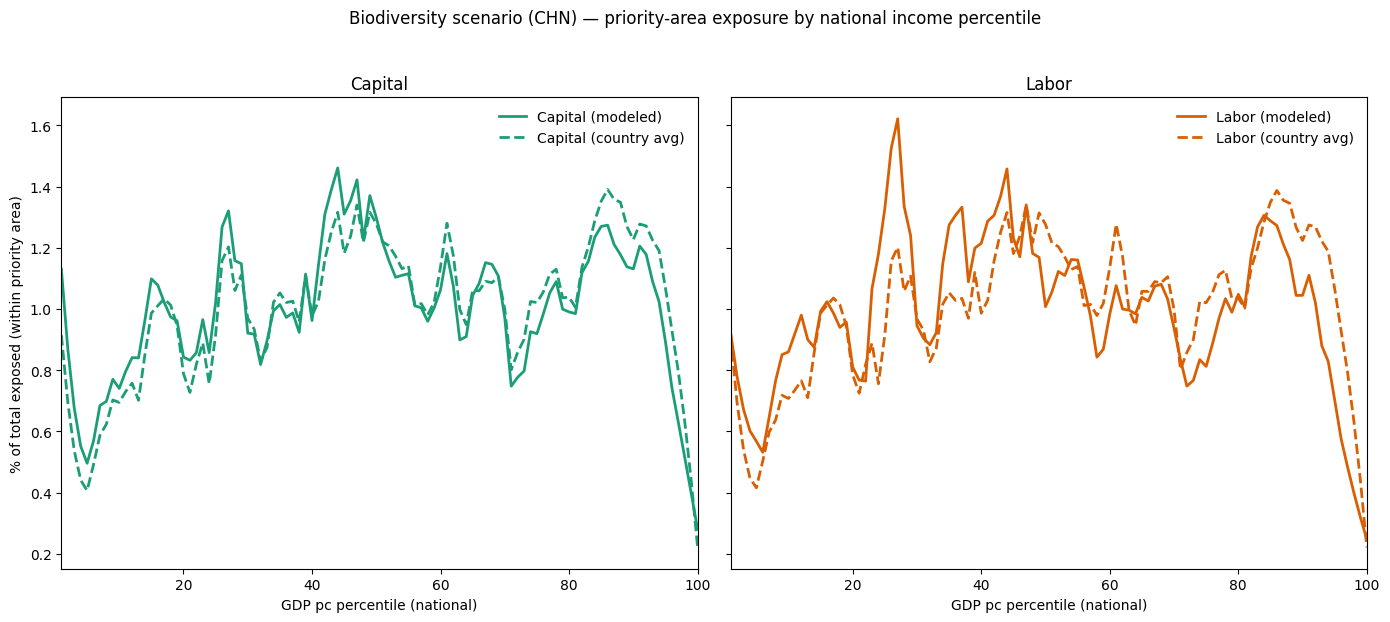

/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_1128/2682992312.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(y, x)          # area under the concentration curve


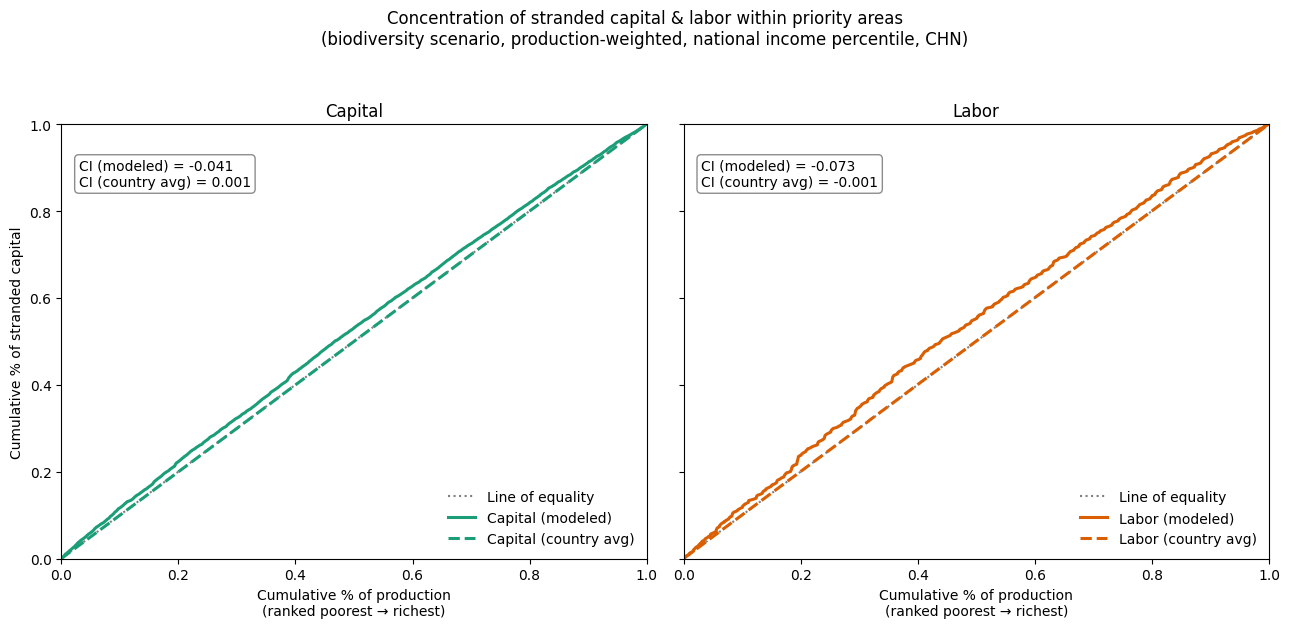

In [50]:
plot_capital_labor_priority(scenario='biodiversity', percentile_scope='national', country='CHN');
plot_concentration_curve(percentile_scope='national', country='CHN');